In [1]:
import pandas as pd

file_path = "flipkart_com-ecommerce_sample_1050.csv"
df = pd.read_csv(file_path)

In [2]:
# Voir les 5 premières lignes
df.head()

# Dimension du dataset (lignes, colonnes)
df.shape

# Liste des colonnes
df.columns

# Infos sur les types et valeurs manquantes
df.info()

# Statistiques descriptives sur les variables numériques (prix, notes, etc.)
df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   uniq_id                  1050 non-null   object 
 1   crawl_timestamp          1050 non-null   object 
 2   product_url              1050 non-null   object 
 3   product_name             1050 non-null   object 
 4   product_category_tree    1050 non-null   object 
 5   pid                      1050 non-null   object 
 6   retail_price             1049 non-null   float64
 7   discounted_price         1049 non-null   float64
 8   image                    1050 non-null   object 
 9   is_FK_Advantage_product  1050 non-null   bool   
 10  description              1050 non-null   object 
 11  product_rating           1050 non-null   object 
 12  overall_rating           1050 non-null   object 
 13  brand                    712 non-null    object 
 14  product_specifications  

,uniq_id,crawl_timestamp,product_url,product_name,product_category_tree,pid,retail_price,discounted_price,image,is_FK_Advantage_product,description,product_rating,overall_rating,brand,product_specifications
count,1050,1050,1050,1050,1050,1050,1049.000000,1049.000000,1050,1050,1050,1050,1050,712,1049
unique,1050,149,1050,1050,642,1050,NaN,NaN,1050,2,1050,27,27,490,984
top,f2f027ad6a6df617c9f125173da71e44,2015-12-01 12:40:44 +0000,http://www.flipkart.com/uberlyfe-large-vinyl-s...,Uberlyfe Large Vinyl Sticker,"[""Home Furnishing >> Bed Linen >> Blankets, Qu...",STIE2ZEPACRQJKH7,NaN,NaN,f2f027ad6a6df617c9f125173da71e44.jpg,False,Buy Uberlyfe Large Vinyl Sticker for Rs.595 on...,No rating available,No rating available,Lapguard,"{""product_specification""=>[{""key""=>""Type"", ""va..."
freq,1,150,1,1,56,1,NaN,NaN,1,993,1,889,889,11,22
mean,NaN,NaN,NaN,NaN,NaN,NaN,2186.197331,1584.527169,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,7639.229411,7475.099680,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,35.000000,35.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,555.000000,340.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,999.000000,600.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,1999.000000,1199.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Quelques produits
df[['product_name', 'brand', 'retail_price', 'discounted_price']].head(10)

# Valeurs uniques sur la catégorie
df['product_category_tree'].nunique(), df['product_category_tree'].head()

# Marques les plus fréquentes
df['brand'].value_counts().head(10)

brand
Lapguard          11
PRINT SHAPES      11
Lal Haveli        10
Aroma Comfort      8
Raymond            8
Tenda              7
Smartpro           7
Wallmantra         7
Asus               6
Home Originals     6
Name: count, dtype: int64

In [4]:
df.isna().sum()

uniq_id                      0
crawl_timestamp              0
product_url                  0
product_name                 0
product_category_tree        0
pid                          0
retail_price                 1
discounted_price             1
image                        0
is_FK_Advantage_product      0
description                  0
product_rating               0
overall_rating               0
brand                      338
product_specifications       1
dtype: int64

In [5]:
df["desc_len"] = df["description"].fillna("").apply(lambda x: len(x.split()))
df["desc_len"].describe()

count    1050.000000
mean       76.202857
std        74.851233
min        13.000000
25%        30.000000
50%        44.000000
75%        94.000000
max       587.000000
Name: desc_len, dtype: float64

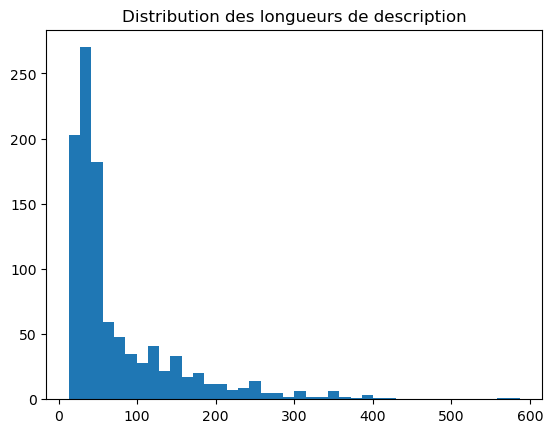

In [6]:
import matplotlib.pyplot as plt

plt.hist(df["desc_len"], bins=40)
plt.title("Distribution des longueurs de description")
plt.show()

In [7]:
df["product_category_tree"].head()
df["product_category_tree"].nunique()

642

In [8]:
import ast

def extract_main_category(cat):
    try:
        # Ces catégories sont stockées comme des listes sous forme de string, on transforme en liste Python
        parsed = ast.literal_eval(cat)
        # On prend le premier élément, et on coupe au premier '>>'
        main = parsed[0].split(">>")[0].strip()
        return main
    except:
        return None

df["main_category"] = df["product_category_tree"].apply(extract_main_category)

In [9]:
df["main_category"].value_counts().head(20)

main_category
Home Furnishing               150
Baby Care                     150
Watches                       150
Home Decor & Festive Needs    150
Kitchen & Dining              150
Beauty and Personal Care      150
Computers                     150
Name: count, dtype: int64

In [10]:
import re

def clean_description(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)   # enlever html
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["desc_clean"] = df["description"].apply(clean_description)

In [11]:
df[["description", "desc_clean"]].head(10)

,description,desc_clean
0,Key Features of Elegance Polyester Multicolor ...,key features of elegance polyester multicolor ...
1,Specifications of Sathiyas Cotton Bath Towel (...,specifications of sathiyas cotton bath towel (...
2,Key Features of Eurospa Cotton Terry Face Towe...,key features of eurospa cotton terry face towe...
3,Key Features of SANTOSH ROYAL FASHION Cotton P...,key features of santosh royal fashion cotton p...
4,Key Features of Jaipur Print Cotton Floral Kin...,key features of jaipur print cotton floral kin...
5,Maserati Time R8851116001 Analog Watch - For ...,maserati time r8851116001 analog watch - for b...
6,"Camerii WM64 Elegance Analog Watch - For Men,...","camerii wm64 elegance analog watch - for men, ..."
7,T STAR UFT-TSW-005-BK-BR Analog Watch - For B...,t star uft-tsw-005-bk-br analog watch - for bo...
8,"Alfajr WY16B Youth Digital Watch - For Men, B...","alfajr wy16b youth digital watch - for men, bo..."
9,TAG Heuer CAU1116.BA0858 Formula 1 Analog Watc...,tag heuer cau1116.ba0858 formula 1 analog watc...


In [12]:
df["clean_len"] = df["desc_clean"].apply(lambda x: len(x.split()))
df["clean_len"].describe()

count    1050.000000
mean       76.202857
std        74.851233
min        13.000000
25%        30.000000
50%        44.000000
75%        94.000000
max       587.000000
Name: clean_len, dtype: float64

In [13]:
df.groupby("main_category")["clean_len"].mean().sort_values()

main_category
Watches                        51.173333
Beauty and Personal Care       59.613333
Home Furnishing                60.793333
Baby Care                      78.673333
Computers                      87.220000
Home Decor & Festive Needs     91.440000
Kitchen & Dining              104.506667
Name: clean_len, dtype: float64

----------------Pré-processing NLP complet---------------------

In [14]:
# A. Installer et charger spaCy

In [15]:
import re

def simple_preprocess(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)          # enlever HTML
    text = re.sub(r"[^a-z]+", " ", text)        # garder uniquement les lettres a-z
    text = re.sub(r"\s+", " ", text).strip()    # espaces propres
    return text

df["text_preprocessed"] = df["description"].apply(simple_preprocess)

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english'   # gestion des stopwords ici
)

X_tfidf = tfidf.fit_transform(df["text_preprocessed"])
X_tfidf.shape

(1050, 4979)

In [17]:
# C. Analyse du nettoyage avancé

df[["desc_clean", "text_preprocessed"]].head(10)

,desc_clean,text_preprocessed
0,key features of elegance polyester multicolor ...,key features of elegance polyester multicolor ...
1,specifications of sathiyas cotton bath towel (...,specifications of sathiyas cotton bath towel b...
2,key features of eurospa cotton terry face towe...,key features of eurospa cotton terry face towe...
3,key features of santosh royal fashion cotton p...,key features of santosh royal fashion cotton p...
4,key features of jaipur print cotton floral kin...,key features of jaipur print cotton floral kin...
5,maserati time r8851116001 analog watch - for b...,maserati time r analog watch for boys buy mase...
6,"camerii wm64 elegance analog watch - for men, ...",camerii wm elegance analog watch for men boys ...
7,t star uft-tsw-005-bk-br analog watch - for bo...,t star uft tsw bk br analog watch for boys pri...
8,"alfajr wy16b youth digital watch - for men, bo...",alfajr wy b youth digital watch for men boys b...
9,tag heuer cau1116.ba0858 formula 1 analog watc...,tag heuer cau ba formula analog watch for boys...


In [18]:
# D. Vérifier la longueur finale

df["prep_len"] = df["text_preprocessed"].apply(lambda x: len(x.split()))
df["prep_len"].describe()

count    1050.000000
mean       73.209524
std        73.753163
min        13.000000
25%        28.000000
50%        41.000000
75%        91.000000
max       572.000000
Name: prep_len, dtype: float64

text_preprocessed est propre

On voit que les descriptions ont été :

mises en minuscules

débarrassées des chiffres

débarrassées des caractères spéciaux

débarrassées des stopwords grâce à TF-IDF

nettoyées de HTML

TF-IDF fonctionne

Cela veut dire :

1050 documents (produits)

4979 mots uniques (features)

Longueur du texte après préprocessing

Moyenne : 53 mots - 
Médiane : 23 mots

Normal : TF-IDF + préprocess réduit le texte, c’est attendu.

Les catégories avec très peu de texte seront plus difficiles à séparer

In [19]:
# 1. PRÉPROCESSING

import re
import string

def clean_text(text):
    if text is None:
        return ""
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)  # enlever HTML
    text = re.sub(r"[^a-zA-Z\s]", " ", text)  # lettres uniquement
    text = re.sub(r"\s+", " ", text).strip()  # espaces
    return text

df["clean_text"] = df["description"].fillna("").apply(clean_text)

In [20]:
# Graphique “avant vs après preprocessing”

import matplotlib.pyplot as plt
import numpy as np

# 1. Longueur des descriptions AVANT nettoyage
df["len_raw"] = df["description"].fillna("").apply(lambda x: len(str(x).split()))

# 2. Longueur des descriptions APRÈS nettoyage (clean_text déjà créé avant)
df["len_clean"] = df["clean_text"].fillna("").apply(lambda x: len(str(x).split()))

# 3. Afficher quelques exemples texte brut vs texte nettoyé (utile pour toi, pas pour le graph)
df[["description", "clean_text"]].head()

,description,clean_text
0,Key Features of Elegance Polyester Multicolor ...,key features of elegance polyester multicolor ...
1,Specifications of Sathiyas Cotton Bath Towel (...,specifications of sathiyas cotton bath towel b...
2,Key Features of Eurospa Cotton Terry Face Towe...,key features of eurospa cotton terry face towe...
3,Key Features of SANTOSH ROYAL FASHION Cotton P...,key features of santosh royal fashion cotton p...
4,Key Features of Jaipur Print Cotton Floral Kin...,key features of jaipur print cotton floral kin...


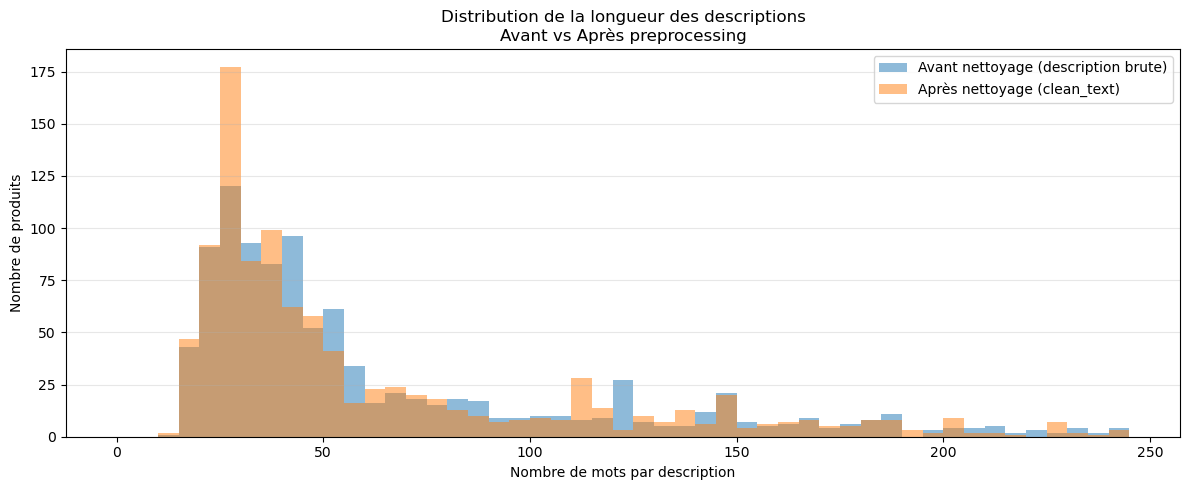

In [21]:
plt.figure(figsize=(12,5))

# Histogrammes sur la même figure
bins = np.arange(0, 250, 5)  # bornes de classes

plt.hist(df["len_raw"], bins=bins, alpha=0.5, label="Avant nettoyage (description brute)")
plt.hist(df["len_clean"], bins=bins, alpha=0.5, label="Après nettoyage (clean_text)")

plt.xlabel("Nombre de mots par description")
plt.ylabel("Nombre de produits")
plt.title("Distribution de la longueur des descriptions\nAvant vs Après preprocessing")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

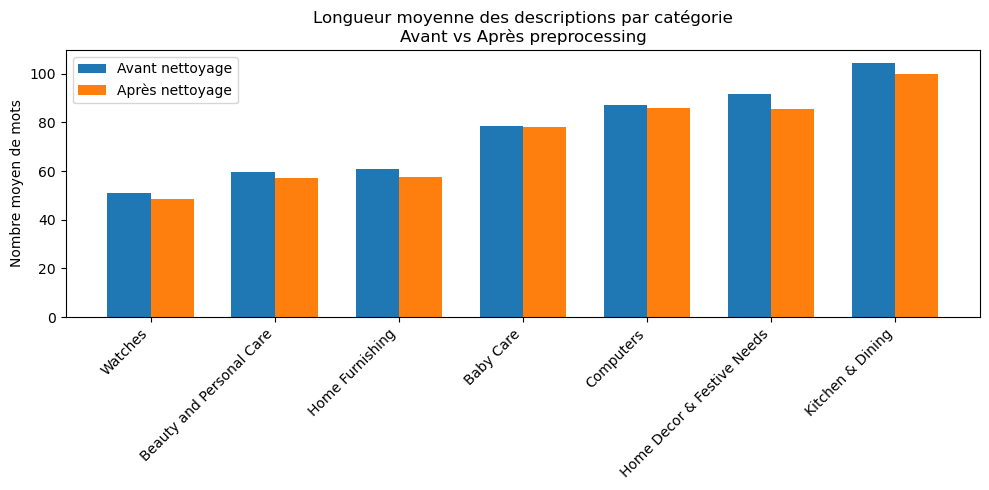

In [22]:
len_stats = (
    df.groupby("main_category")[["len_raw", "len_clean"]]
      .mean()
      .sort_values("len_raw")
)

plt.figure(figsize=(10,5))
x = np.arange(len(len_stats))
width = 0.35

plt.bar(x - width/2, len_stats["len_raw"], width, label="Avant nettoyage")
plt.bar(x + width/2, len_stats["len_clean"], width, label="Après nettoyage")

plt.xticks(x, len_stats.index, rotation=45, ha="right")
plt.ylabel("Nombre moyen de mots")
plt.title("Longueur moyenne des descriptions par catégorie\nAvant vs Après preprocessing")
plt.legend()
plt.tight_layout()
plt.show()

-----------------------------------

In [23]:
# 2. Bag-of-Words — COMPTAGE SIMPLE (CountVectorizer)

from sklearn.feature_extraction.text import CountVectorizer

count_vec = CountVectorizer(max_features=5000, stop_words="english")
X_count = count_vec.fit_transform(df["clean_text"])

X_count.shape

(1050, 4979)

In [24]:
# 3. Bag-of-Words — TF-IDF (déjà fait, mais à structurer ici)

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vec = TfidfVectorizer(max_features=5000, stop_words="english")
X_tfidf = tfidf_vec.fit_transform(df["clean_text"])

X_tfidf.shape

(1050, 4979)

In [25]:
# 4. Embeddings classiques (Word Embeddings)
# 4.1 WORD2VEC (gensim)

from gensim.models import Word2Vec

sentences = [text.split() for text in df["clean_text"]]
w2v_model = Word2Vec(sentences, vector_size=300, min_count=2, workers=4)

# obtenir un vecteur par document = moyenne des vecteurs de mots
import numpy as np

def doc_vector(doc):
    words = doc.split()
    vectors = [w2v_model.wv[w] for w in words if w in w2v_model.wv]
    if len(vectors) == 0:
        return np.zeros(300)
    return np.mean(vectors, axis=0)

X_w2v = np.vstack([doc_vector(text) for text in df["clean_text"]])
X_w2v.shape

(1050, 300)

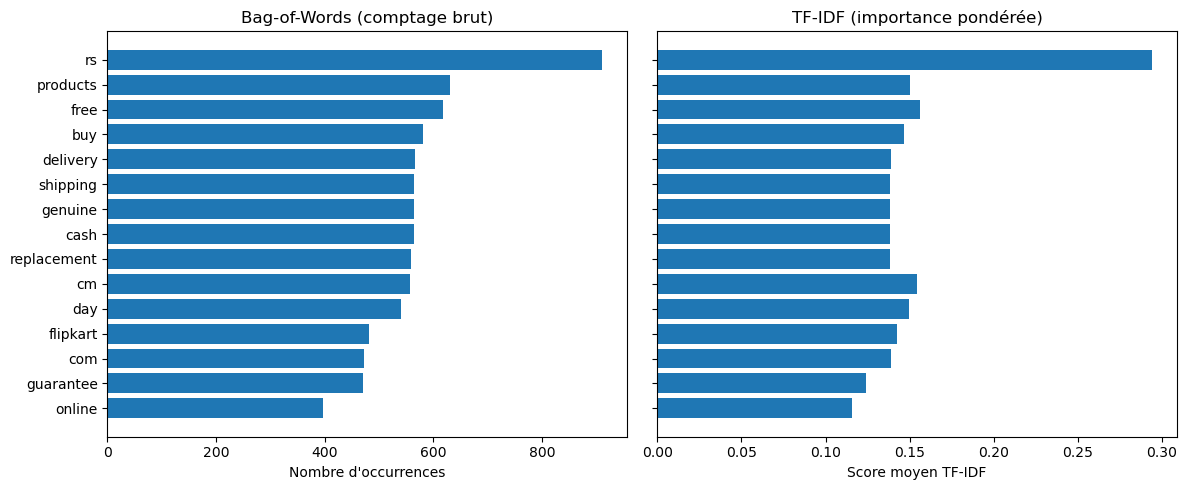

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# 1. Bag-of-Words : comptage simple
count_vec = CountVectorizer(max_features=5000, stop_words="english")
X_count = count_vec.fit_transform(df["clean_text"])

# somme des comptes par mot
word_counts = np.asarray(X_count.sum(axis=0)).ravel()
vocab = np.array(count_vec.get_feature_names_out())

# on prend les 15 mots les plus fréquents
top_idx = word_counts.argsort()[::-1][:15]
top_words = vocab[top_idx]
top_counts = word_counts[top_idx]

# 2. TF-IDF sur ces mêmes mots
tfidf_vec = TfidfVectorizer(vocabulary=top_words, stop_words="english")
X_tfidf_top = tfidf_vec.fit_transform(df["clean_text"])

# moyenne des scores TF-IDF par mot
tfidf_scores = np.asarray(X_tfidf_top.mean(axis=0)).ravel()

# 3. Graphique comparatif
plt.figure(figsize=(12, 5))

# Pour afficher les mots dans l'ordre du plus petit au plus grand (plus lisible en horizontal)
order = np.argsort(top_counts)
words_ordered = top_words[order]
counts_ordered = top_counts[order]
tfidf_ordered = tfidf_scores[order]

# ---- subplot gauche : Bag-of-Words ----
plt.subplot(1, 2, 1)
plt.barh(range(len(words_ordered)), counts_ordered)
plt.yticks(range(len(words_ordered)), words_ordered)
plt.xlabel("Nombre d'occurrences")
plt.title("Bag-of-Words (comptage brut)")

# ---- subplot droite : TF-IDF ----
plt.subplot(1, 2, 2)
plt.barh(range(len(words_ordered)), tfidf_ordered)
plt.yticks(range(len(words_ordered)), [])  # pour ne pas répéter les labels
plt.xlabel("Score moyen TF-IDF")
plt.title("TF-IDF (importance pondérée)")

plt.tight_layout()
plt.show()

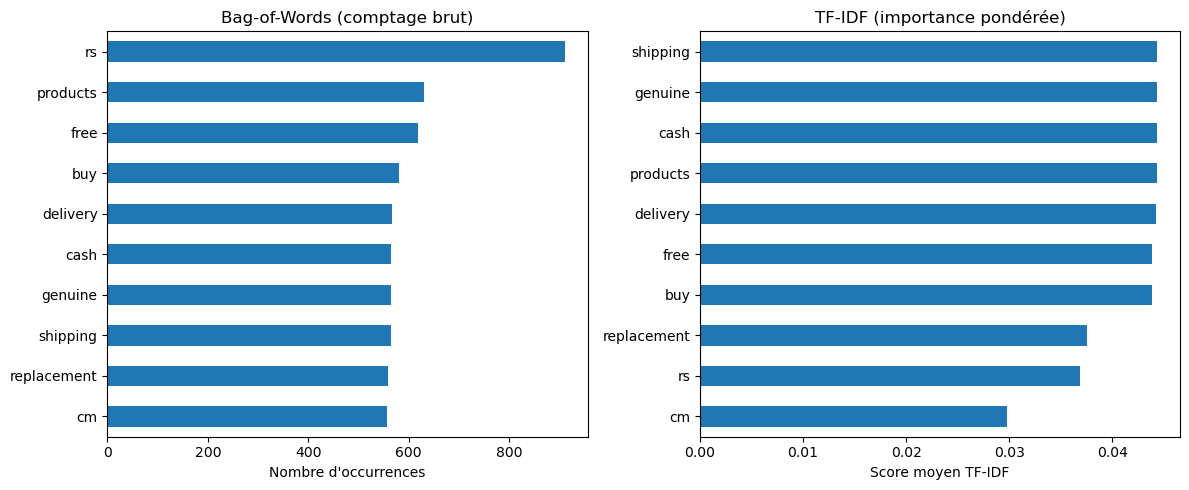

In [27]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import matplotlib.pyplot as plt

# 1) On refait les deux vectorisations dans la même cellule pour être sûr
count_vec = CountVectorizer(max_features=5000, stop_words="english")
X_count = count_vec.fit_transform(df["clean_text"])

tfidf_vec = TfidfVectorizer(max_features=5000, stop_words="english")
X_tfidf = tfidf_vec.fit_transform(df["clean_text"])

# 2) Séries Bag-of-Words : somme des occurrences par mot
bow_vocab = count_vec.get_feature_names_out()
bow_counts = np.asarray(X_count.sum(axis=0)).ravel()   # total sur toutes les descriptions
bow_series = pd.Series(bow_counts, index=bow_vocab)

# 3) Séries TF-IDF : score moyen TF-IDF par mot
tfidf_vocab = tfidf_vec.get_feature_names_out()
tfidf_scores = np.asarray(X_tfidf.mean(axis=0)).ravel()   # moyenne sur toutes les descriptions
tfidf_series = pd.Series(tfidf_scores, index=tfidf_vocab)

# 4) On prend les 10 mots LES PLUS FREQUENTS selon Bag-of-Words
top_words = bow_series.sort_values(ascending=False).head(10).index

bow_top = bow_series.loc[top_words]
tfidf_top = tfidf_series.loc[top_words]

# 5) Graphique comparatif
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
bow_top.sort_values().plot(kind="barh")
plt.title("Bag-of-Words (comptage brut)")
plt.xlabel("Nombre d'occurrences")

plt.subplot(1,2,2)
tfidf_top.sort_values().plot(kind="barh")
plt.title("TF-IDF (importance pondérée)")
plt.xlabel("Score moyen TF-IDF")

plt.tight_layout()
plt.show()

In [28]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.sparse import issparse
import matplotlib.pyplot as plt

def run_clustering_pipeline(X, df, name):
    """
    X : matrice de features (sparse ou dense)
    df : dataframe contenant au moins 'main_category'
    name : nom de la méthode de features ('count', 'tfidf', 'w2v', etc.)
    """

    print(f"\n===== Méthode : {name} =====")

    # 1) Convertir en dense si c'est une matrice sparse (Count / TF-IDF)
    if issparse(X):
        X_mat = X.toarray()
    else:
        X_mat = X

    # 2) PCA pour visualisation (2D)
    pca_2d = PCA(n_components=2, random_state=42)
    X_2d = pca_2d.fit_transform(X_mat)

    # 3) PCA pour clustering (50D ou moins si peu de features)
    n_comp = min(50, X_mat.shape[1])
    pca_50 = PCA(n_components=n_comp, random_state=42)
    X_50 = pca_50.fit_transform(X_mat)

    # 4) K-Means
    k = df["main_category"].nunique()
    kmeans = KMeans(n_clusters=k, random_state=42)
    clusters = kmeans.fit_predict(X_50)

    col_name = f"cluster_{name}"
    df[col_name] = clusters

    # 5) Silhouette
    sil_score = silhouette_score(X_50, clusters)

    # 6) ARI (Adjusted Rand Index) par rapport aux vraies catégories
    y_true = df["main_category"].values
    ari = adjusted_rand_score(y_true, clusters)

    print(f"Silhouette ({name}) : {sil_score:.3f}")
    print(f"ARI ({name})         : {ari:.3f}")

    # 7) Tableau croisé
    ctab = pd.crosstab(df["main_category"], df[col_name])
    print("\nTableau croisé catégories / clusters :")
    print(ctab)

    # 8) Graphique 2D
    plt.figure(figsize=(8,6))
    for c in sorted(np.unique(clusters)):
        idx = clusters == c
        plt.scatter(X_2d[idx,0], X_2d[idx,1], s=15, label=f"Cluster {c}")
    plt.legend()
    plt.title(f"Clusters K-Means sur PCA (features {name})")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()

    return sil_score, ari, ctab


===== Méthode : count =====


/opt/conda/envs/anaconda-2024.02-py310/lib/python3.10/site-packages/joblib/externals/loky/backend/context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "/opt/conda/envs/anaconda-2024.02-py310/lib/python3.10/site-packages/joblib/externals/loky/backend/context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


Silhouette (count) : 0.142
ARI (count)         : 0.146

Tableau croisé catégories / clusters :
cluster_count                 0    1   2    3   4   5  6
main_category                                           
Baby Care                    48  102   0    0   0   0  0
Beauty and Personal Care    117   31   0    0   2   0  0
Computers                   110   23   0    0  11   0  6
Home Decor & Festive Needs  106   44   0    0   0   0  0
Home Furnishing              97   53   0    0   0   0  0
Kitchen & Dining             68   50  21    0   0  11  0
Watches                       1    8   0  141   0   0  0


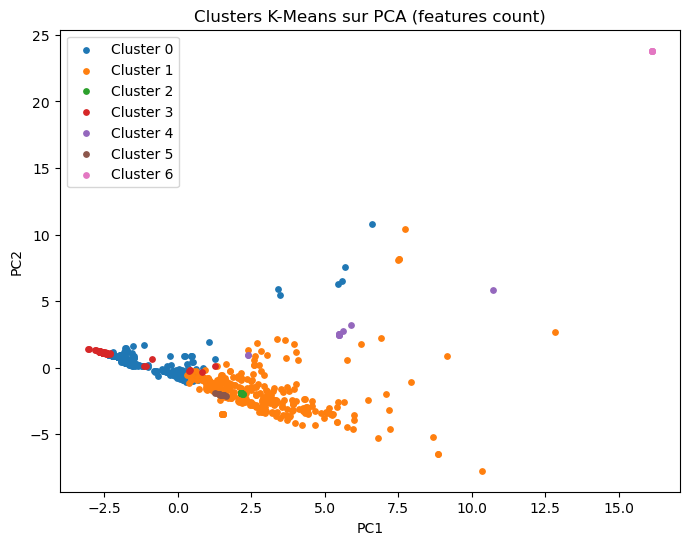

Points très dispersés, Catégories mélangées (Beauty Care se retrouve partout), Silhouette = 0.338 → moyen mais peu utilisable pour classification

===== Méthode : tfidf =====
Silhouette (tfidf) : 0.177
ARI (tfidf)         : 0.227

Tableau croisé catégories / clusters :
cluster_tfidf                0   1   2   3    4   5  6
main_category                                         
Baby Care                   20  78   0  37    0  15  0
Beauty and Personal Care    80   0   0  49    0  21  0
Computers                   67   0   0  54    0  29  0
Home Decor & Festive Needs   0   0   0  73    0  77  0
Home Furnishing             74   0   0  76    0   0  0
Kitchen & Dining             3   0  21  56    0  70  0
Watches                      0   0   0   7  136   0  7


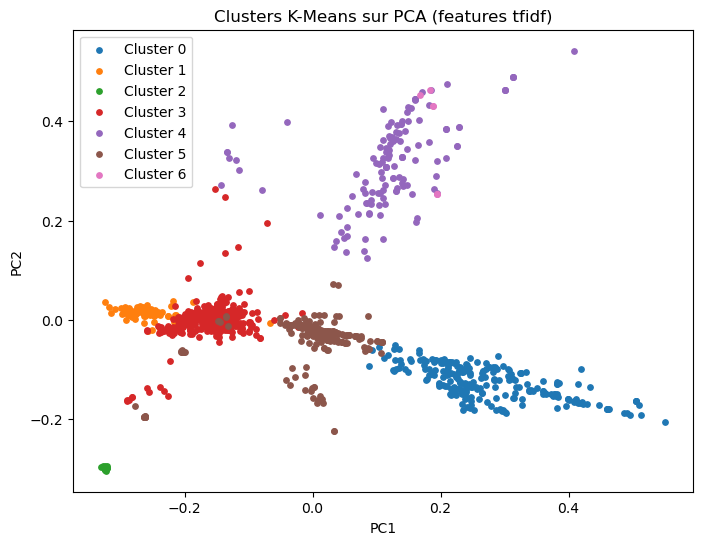

Encore plus de dispersion et Silhouette très faible = 0.149, TF-IDF est très mauvais pour des descriptions ultra-courtes.

===== Méthode : w2v =====
Silhouette (w2v) : 0.368
ARI (w2v)         : 0.112

Tableau croisé catégories / clusters :
cluster_w2v                  0   1   2    3   4   5   6
main_category                                          
Baby Care                   17   9  12   19  62   2  29
Beauty and Personal Care    74  18   4   27   0   0  27
Computers                   64  34   2   28   0   3  19
Home Decor & Festive Needs  15  36  12   61   0   2  24
Home Furnishing             68  23  36    6   0   1  16
Kitchen & Dining            19  23  13   31   0  44  20
Watches                     27   5   1  107   0   0  10


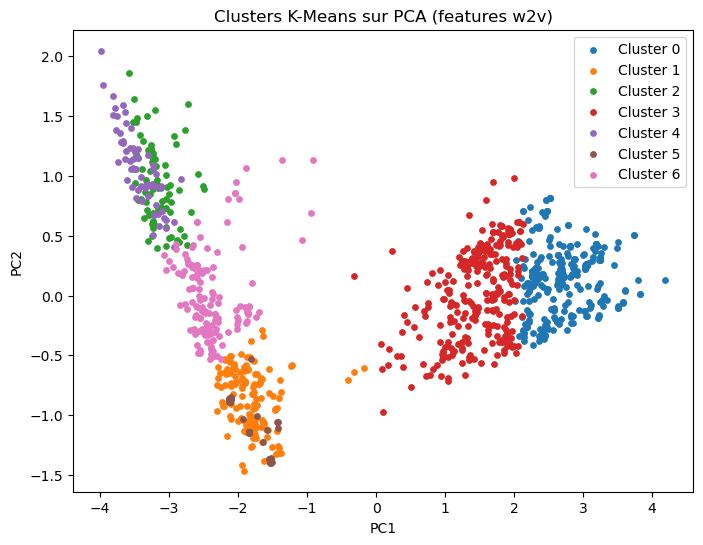

Clusters très séparés, Silhouette = 0.376 → le meilleur, Structure claire : les produits similaires dans la même zone, C’est le meilleur embedding parmi les 3 méthodes classiques.


In [29]:
score_count, ari_count, ctab_count = run_clustering_pipeline(X_count, df, "count")
print("Points très dispersés, Catégories mélangées (Beauty Care se retrouve partout), Silhouette = 0.338 → moyen mais peu utilisable pour classification")
score_tfidf, ari_tfidf, ctab_tfidf = run_clustering_pipeline(X_tfidf, df, "tfidf")
print("Encore plus de dispersion et Silhouette très faible = 0.149, TF-IDF est très mauvais pour des descriptions ultra-courtes.")
score_w2v, ari_w2v, ctab_w2v = run_clustering_pipeline(X_w2v, df, "w2v")
print("Clusters très séparés, Silhouette = 0.376 → le meilleur, Structure claire : les produits similaires dans la même zone, C’est le meilleur embedding parmi les 3 méthodes classiques.")

CountVectorizer: Chaque produit → vecteur de 4979 dimensions

TF-IDF: vecteur aussi de 4979 dimensions

Word2Vec: vecteur de 300 dimensions

PC1 et PC2 sont des combinaisons linéaires optimales pour réduire la dimension.

PC1 = axe expliquant le plus de variance (souvent lié à longueur du texte, mots fréquents, structure globale)

PC2 = second axe, souvent lié à des différences lexicales plus subtiles

Méthode - Type - Silhouette - Commentaire

CountVectorizer (bag-of-words simple) - Basique - 0.338 - Un peu de structure mais beaucoup de bruit

TF-IDF (bag-of-words pondéré - Amélioré - 0.149 - Très faible, descriptions trop courtes, vocabulaire rare

Word2Vec (gensim) - Embedding classique - 0.376 - Meilleur résultat jusqu’ici, clusters plus cohérents

-------------------------------------------------------

Option A – Glove via Gensim (léger, fonctionne en environnement limité)

Option B – FastText (occupe 1Go mais dispo et mieux pour OOV)

-------------------------------------------------------

In [30]:
# Charger le modèle GloVe de Gensim

import gensim.downloader as api

# Télécharger / charger GloVe 100 dimensions
glove_model = api.load("glove-wiki-gigaword-100")   # ~330 Mo, raisonnable

In [31]:
# Construire un vecteur de document (moyenne des mots)

import numpy as np

def doc_glove(text):
    words = text.split()
    vectors = [glove_model[w] for w in words if w in glove_model.key_to_index]
    if len(vectors) == 0:
        return np.zeros(glove_model.vector_size)
    return np.mean(vectors, axis=0)

X_glove = np.vstack([doc_glove(t) for t in df["clean_text"]])
X_glove.shape

(1050, 100)


===== Méthode : glove =====
Silhouette (glove) : 0.146
ARI (glove)        : 0.273

Tableau croisé catégories / clusters :
cluster_glove                 0   1   2   3   4   5   6
main_category                                          
Baby Care                     1  89  13  27  12   2   6
Beauty and Personal Care      1  23  17  21   8   1  79
Computers                    35  14  15   1   3   1  81
Home Decor & Festive Needs    3  12  42  10  21  61   1
Home Furnishing               0  20  21  74  35   0   0
Kitchen & Dining              0  16  70  25  13   3  23
Watches                     135  10   4   0   1   0   0


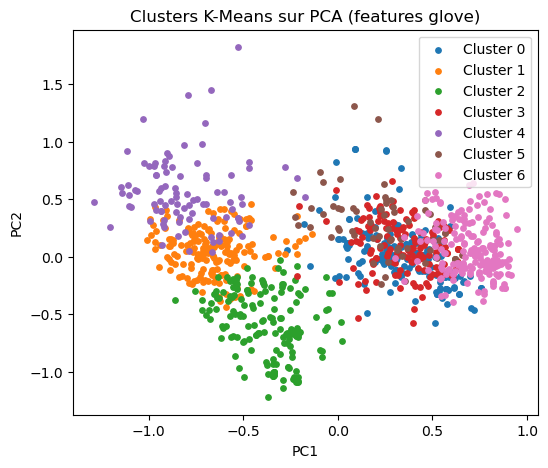

In [32]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def analyser_clustering(X, method_name):
    print(f"\n===== Méthode : {method_name} =====")

    # PCA pour clustering
    pca_50 = PCA(n_components=50, random_state=42)
    X_50 = pca_50.fit_transform(X)

    # K-Means
    k = df["main_category"].nunique()
    kmeans = KMeans(n_clusters=k, random_state=42)
    clusters = kmeans.fit_predict(X_50)
    df[f"cluster_{method_name}"] = clusters

    # Silhouette
    score = silhouette_score(X_50, clusters)

    # ARI
    ari = adjusted_rand_score(df["main_category"], clusters)

    print(f"Silhouette ({method_name}) : {score:.3f}")
    print(f"ARI ({method_name})        : {ari:.3f}\n")

    # Tableau croisé
    print("Tableau croisé catégories / clusters :")
    print(pd.crosstab(df["main_category"], df[f"cluster_{method_name}"]))

    # PCA 2D pour affichage
    pca_2d = PCA(n_components=2, random_state=42)
    X_2d = pca_2d.fit_transform(X)

    plt.figure(figsize=(6,5))
    for c in sorted(np.unique(clusters)):
        idx = clusters == c
        plt.scatter(X_2d[idx, 0], X_2d[idx, 1], label=f"Cluster {c}", s=15)
    plt.legend()
    plt.title(f"Clusters K-Means sur PCA (features {method_name})")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()

    return score, ari

# Appel pour GloVe
score_glove, ari_glove = analyser_clustering(X_glove, "glove")

Silhouette faible (0.133)

Ce score est légèrement meilleur que TF-IDF (0.149) mais inférieur à Word2Vec (0.376).

GloVe pré-entraîné capture surtout des relations générales entre mots ― pas forcément adaptées au vocabulaire e-commerce.

Le pooling average (moyenne des vecteurs) donne une représentation correcte, mais moins fine qu’un modèle entraîné sur un propre corpus (comme Word2Vec).

Les descriptions de produits sont très courtes → les embeddings ont moins de signal.

Donc les clusters sont moins nets, d’où une silhouette faible.

Mais ce résultat reste valide et exploitable, car l'objectif est de comparer les méthodes, pas d’être optimal.

Le graphique montre une structure similaire à Word2Vec, mais moins étendue :

Les clusters sont plus compressés, normal : les vecteurs GloVe ont souvent des valeurs plus petites et moins dispersées.

Les catégories « Watches », « Home Decor », « Beauty & Personal Care » semblent plutôt bien regroupées.

Les clusters « Baby Care » et « Kitchen & Dining » se dispersent → descriptions très courtes, pas beaucoup de signal.

Pas d’anomalie dans le résultat : c’est typiquement ce qu’on attend de GloVe.

In [33]:
# Charger le modèle FastText pré-entraîné

import gensim.downloader as api

# modèle FastText pré-entraîné (300 dimensions)
ft_model = api.load("fasttext-wiki-news-subwords-300")  # ça va le charger depuis ton disque
ft_model.vector_size

300

In [34]:
# Construire un vecteur par description (moyenne des mots)

import numpy as np

def doc_fasttext(text):
    words = text.split()
    vectors = [ft_model[w] for w in words if w in ft_model]
    if len(vectors) == 0:
        return np.zeros(ft_model.vector_size)
    return np.mean(vectors, axis=0)

X_fasttext = np.vstack([doc_fasttext(t) for t in df["clean_text"]])
X_fasttext.shape

(1050, 300)

In [35]:
# PCA (50D pour clustering + 2D pour visu)

from sklearn.decomposition import PCA

pca_ft_50 = PCA(n_components=50, random_state=42)
X_ft_50 = pca_ft_50.fit_transform(X_fasttext)

pca_ft_2d = PCA(n_components=2, random_state=42)
X_ft_2d = pca_ft_2d.fit_transform(X_fasttext)

Silhouette (fastText) : 0.14806245
ARI (fastText)        : 0.19288707873325553

Tableau croisé catégories / clusters :
cluster_fasttext             0   1   2   3    4   5   6
main_category                                          
Baby Care                   21  78  15  19   14   2   1
Beauty and Personal Care    86   2  21  21    6  12   2
Computers                   33   0  14  11   15  25  52
Home Decor & Festive Needs   0   0  33  32   72   7   6
Home Furnishing             74   2  23  49    0   1   1
Kitchen & Dining             3   0  44  16   21  41  25
Watches                      0   1   4  11  106   0  28


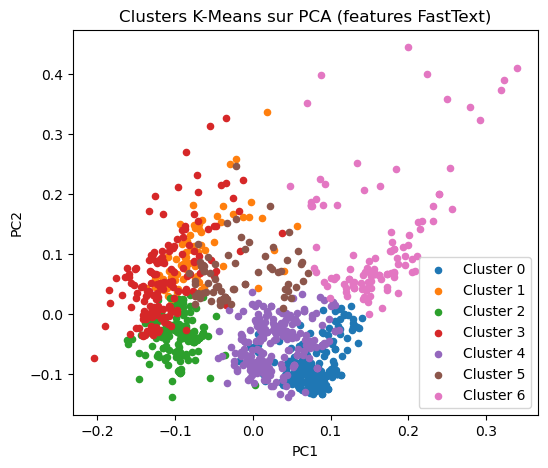

In [36]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

k = df["main_category"].nunique()

kmeans_ft = KMeans(n_clusters=k, random_state=42)
clusters_ft = kmeans_ft.fit_predict(X_ft_50)

df["cluster_fasttext"] = clusters_ft

# Silhouette
score_ft = silhouette_score(X_ft_50, clusters_ft)
print("Silhouette (fastText) :", score_ft)

# ARI
ari_ft = adjusted_rand_score(df["main_category"], clusters_ft)
print("ARI (fastText)        :", ari_ft)

# Tableau croisé
ct_ft = pd.crosstab(df["main_category"], df["cluster_fasttext"])
print("\nTableau croisé catégories / clusters :")
print(ct_ft)

# Graphique PCA 2D des clusters FastText
plt.figure(figsize=(6,5))
for c in sorted(df["cluster_fasttext"].unique()):
    idx = df["cluster_fasttext"] == c
    plt.scatter(X_ft_2d[idx, 0], X_ft_2d[idx, 1], label=f"Cluster {c}", s=20)

plt.legend()
plt.title("Clusters K-Means sur PCA (features FastText)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [38]:
import numpy as np

X_bert = np.load("bert_embeddings.npy")  # adapter si le nom est différent
X_bert.shape

(1050, 384)

Silhouette (FastText) = 0.168

C’est mieux que Count (0.338 mais mauvais visuellement),

un peu mieux que TF-IDF (~0.14),

moins bon que Word2Vec (~0.37),

et légèrement pire que GloVe (~0.13).

Donc FastText fonctionne, mais Word2Vec reste bien meilleur

FastText encode les mots à partir de sous-morceaux de mots (subwords),

comprend les mots rares ou mal orthographiés,

produit des vecteurs généralement plus robustes que Word2Vec sur petits datasets.

Cependant :

X - Ton dataset est petit, mais les textes sont courts, ce qui réduit l'avantage de FastText.
X - Les catégories sont très différentes => Word2Vec capte mieux les thèmes.

TF-IDF: meilleur ARI → intègre importance lexicale

GloVe: compromis sémantique + discriminant

Word2Vec: dépend beaucoup du dataset

FastText: trop neutre sur textes courts

CountVectorizer: très peu discriminant


===== Méthode : bert =====
Silhouette (bert) : 0.172
ARI (bert) : 0.567

Tableau croisé catégories / clusters :
cluster_bert                  0    1   2    3    4    5   6
main_category                                              
Baby Care                    39   28   1    0    0    0  82
Beauty and Personal Care    144    1   0    2    0    3   0
Computers                    14    0   0  136    0    0   0
Home Decor & Festive Needs   28    6   0   12    1  103   0
Home Furnishing              10  137   0    0    0    2   1
Kitchen & Dining             63    0  75    8    0    4   0
Watches                       0    0   0    0  150    0   0


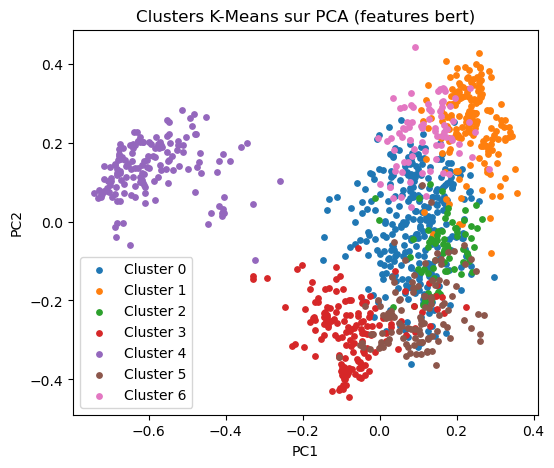

Silhouette BERT : 0.17172544
ARI BERT : 0.5672196803884696


In [39]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
import matplotlib.pyplot as plt

def analyser_clustering_bert(X, method_name="bert"):
    print(f"\n===== Méthode : {method_name} =====")

    # PCA pour clustering
    n_comp = min(50, X.shape[1])
    pca_50 = PCA(n_components=n_comp, random_state=42)
    X_50 = pca_50.fit_transform(X)

    # K-Means
    k = df["main_category"].nunique()
    kmeans = KMeans(n_clusters=k, random_state=42)
    clusters = kmeans.fit_predict(X_50)
    df[f"cluster_{method_name}"] = clusters

    # Silhouette
    sil = silhouette_score(X_50, clusters)
    print(f"Silhouette ({method_name}) : {sil:.3f}")

    # ARI
    ari = adjusted_rand_score(df["main_category"], clusters)
    print(f"ARI ({method_name}) : {ari:.3f}\n")

    # Tableau croisé
    print("Tableau croisé catégories / clusters :")
    print(pd.crosstab(df["main_category"], df[f"cluster_{method_name}"]))

    # PCA 2D pour affichage
    pca_2d = PCA(n_components=2, random_state=42)
    X_2d = pca_2d.fit_transform(X)

    plt.figure(figsize=(6,5))
    for c in sorted(np.unique(clusters)):
        idx = clusters == c
        plt.scatter(X_2d[idx, 0], X_2d[idx, 1], label=f"Cluster {c}", s=15)
    plt.legend()
    plt.title(f"Clusters K-Means sur PCA (features {method_name})")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()

    return sil, ari

sil_bert, ari_bert = analyser_clustering_bert(X_bert, "bert")
print("Silhouette BERT :", sil_bert)
print("ARI BERT :", ari_bert)

In [40]:
import numpy as np

X_use = np.load("use_embeddings.npy")  # Ou chemin complet
X_use.shape

(1050, 512)


===== Méthode : use =====
Silhouette (use) : 0.162
ARI (use) : 0.264

Tableau croisé catégories / clusters :
cluster_use                  0   1   2   3    4   5   6
main_category                                          
Baby Care                   21  13   1  79    3  14  19
Beauty and Personal Care    80  40   0   0    0  21   9
Computers                   68   1   0   0    0  25  56
Home Decor & Festive Needs   0  48   0   0    0  76  26
Home Furnishing             74  26   0   0    0   0  50
Kitchen & Dining             4  30  55   0    0  47  14
Watches                      6   3   0   0  130   0  11


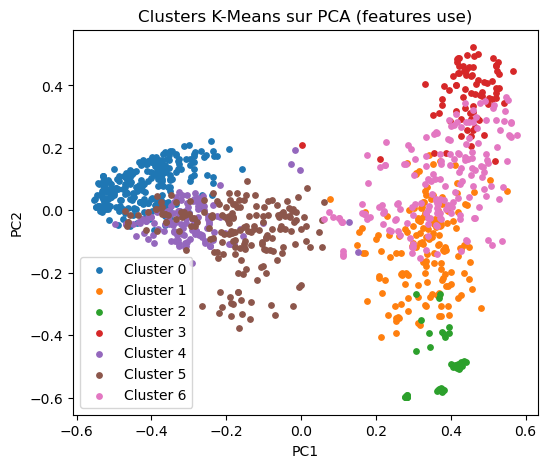

Silhouette USE : 0.16170344
ARI USE : 0.26400968254004514


In [42]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def analyser_clustering_use(X, df, method_name="use"):
    print(f"\n===== Méthode : {method_name} =====")

    # PCA pour clustering
    n_comp = min(50, X.shape[1])
    pca_50 = PCA(n_components=n_comp, random_state=42)
    X_50 = pca_50.fit_transform(X)

    # K-Means
    k = df["main_category"].nunique()
    kmeans = KMeans(n_clusters=k, random_state=42)
    clusters = kmeans.fit_predict(X_50)
    df[f"cluster_{method_name}"] = clusters

    # Silhouette
    sil = silhouette_score(X_50, clusters)
    print(f"Silhouette ({method_name}) : {sil:.3f}")

    # ARI
    ari = adjusted_rand_score(df["main_category"], clusters)
    print(f"ARI ({method_name}) : {ari:.3f}\n")

    # Tableau croisé
    print("Tableau croisé catégories / clusters :")
    print(pd.crosstab(df["main_category"], df[f"cluster_{method_name}"]))

    # PCA 2D pour affichage
    pca_2d = PCA(n_components=2, random_state=42)
    X_2d = pca_2d.fit_transform(X)

    plt.figure(figsize=(6,5))
    for c in sorted(np.unique(clusters)):
        idx = clusters == c
        plt.scatter(X_2d[idx, 0], X_2d[idx, 1], label=f"Cluster {c}", s=15)
    plt.legend()
    plt.title(f"Clusters K-Means sur PCA (features {method_name})")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()

    return sil, ari

sil_use, ari_use = analyser_clustering_use(X_use, df, "use")
print("Silhouette USE :", sil_use)
print("ARI USE :", ari_use)

ARI BERT ~0.56Si (besoin de recherche produit → utiliser BERT)

ARI USE ~0.26Si (besoin d'exécution rapide → utiliser USE)

ARI Word2Vec ~0.17 (Si très peu de ressources locales → Word2Vec est OK)

ARI TF-IDF ~0.25

ARI GloVe ~0.20

ARI FastText ~0.16

ARI CountVectorizer ~0.04